notebook creates figures of the cooling / regional temperature annual mean timseries under HiLLA and SSP245 scenarios

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, UKESM_ARISE_run_IDs, ens_mems_CE, colours, model_colors

## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [2]:
## UKESM (note the combined run u-dm204dn587 is the 35 year run for 13km 60°)
ds_HiLLA_13_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dm204dn587', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')
ds_HiLLA_15_UK = weighted_annual_resample(cut_incomplete_years(get_ds(run = 'u-dn760', var='tas', table='Amon').sel(time=slice(None, '2069'))), var='tas')

## repeat for CESM
ds_HiLLA_13_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case01_60NS_13km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_CE = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/Temperature/case04_60NS_15km_MAMJ_6Tg_TREFHT.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## repeat for E3SM
ds_HiLLA_13_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.01.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')
ds_HiLLA_15_E3 = weighted_annual_resample(set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.04.nc'), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'}).sel(time=slice(None, '2069')), var='tas')

## combine into a dict
HiLLA_data = {'UKESM':{'13km':ds_HiLLA_13_UK, '15km':ds_HiLLA_15_UK},
              'CESM':{'13km':ds_HiLLA_13_CE, '15km':ds_HiLLA_15_CE},
              'E3SM':{'13km':ds_HiLLA_13_E3, '15km':ds_HiLLA_15_E3}}

## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        data = HiLLA_data[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_timeseries_dict = dict(zip(models, timeseries_dicts_models))

In [3]:
DS_ssp245_tas_UK = weighted_annual_resample(get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

DS_ssp245_tas_CE = weighted_annual_resample(get_ds_from_ceda(model='CESM2-WACCM', centre='NCAR', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='tas', members=ens_mems_CE, 
                              table='Amon', grid='gn'), var='tas').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})

ds_ssp245_tas_E3 =  xr.open_dataset(path_archive+'E3SM_data/regridded/Temperature/TREFHT.polar.mip.e3sm.control.nc').rename({'lat':'latitude', 'lon':'longitude', 'TREFHT':'tas'})
ds_ssp245_tas_E3 = weighted_annual_resample(cut_incomplete_years(ds_ssp245_tas_E3), var='tas').sel(time=slice('2015', '2069'))
DS_ssp245_tas_E3 = xr.concat([ds_ssp245_tas_E3], dim='Ensemble_member')
#ds_ssp245_tas_E3['Ensemble_member'] = 'r1'

SSP245_data = {'UKESM':DS_ssp245_tas_UK, 'CESM':DS_ssp245_tas_CE, 'E3SM':DS_ssp245_tas_E3}

## reduce SSP2-4.5 data to annually resampled timeseries
timeseries_dicts = []
for model in models:
    print(model)
    data = SSP245_data[model].load()
    timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))
    
SSP245_timeseries_dict = dict(zip(models, timeseries_dicts))

UKESM
CESM
E3SM


In [4]:
### save cooling maps to intermediate outputs for re-use elsewhere:
for model in models:
    for alt in ['13km', '15km']:
        cooling = HiLLA_data[model][alt] - SSP245_data[model].mean('Ensemble_member')
        cooling.to_netcdf('../intermediate_outputs/cooling_annual/{m}_HiLLA-{a}_cooling.nc'.format(m=model, a=alt))

In [5]:
matplotlib.rcParams.update({'font.size': 15})

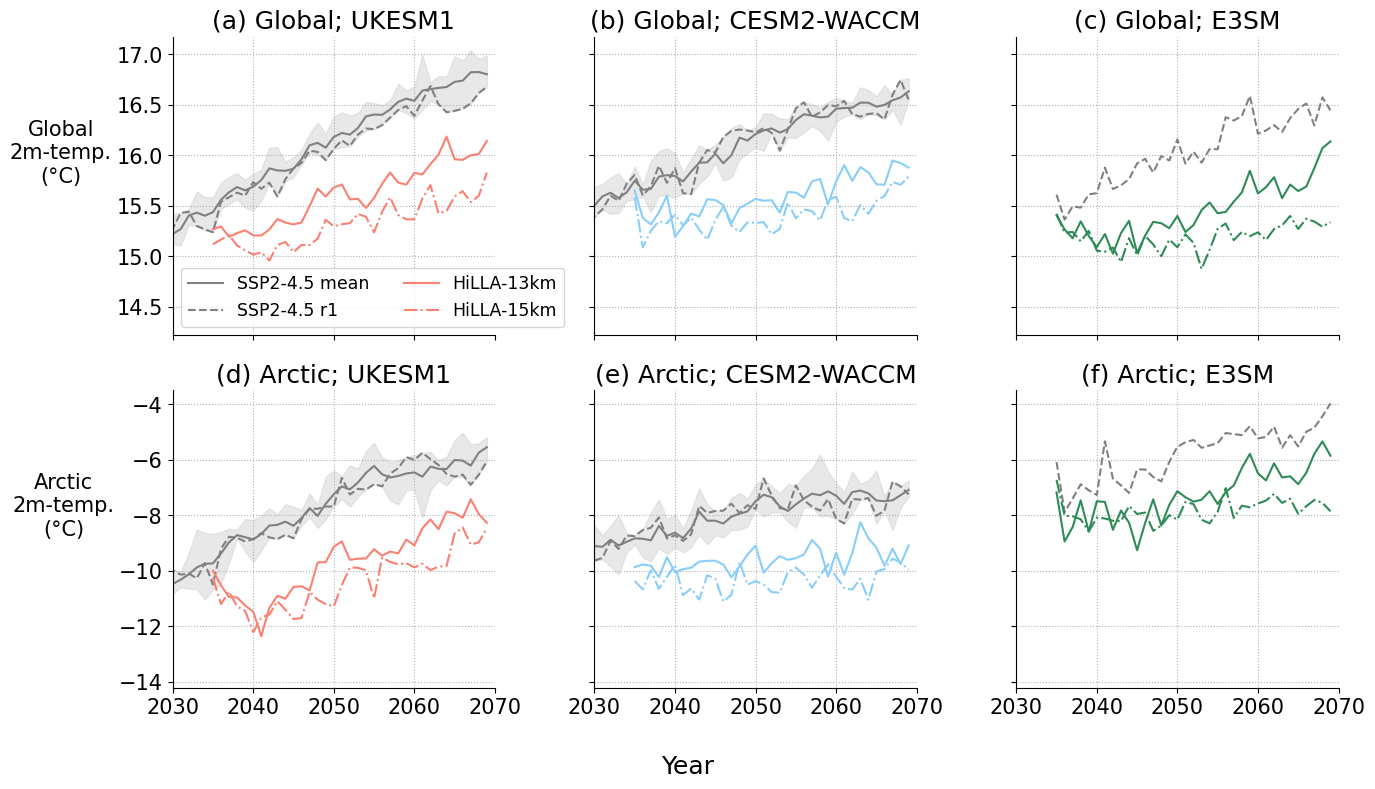

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}
kelvinconv = 273.15

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=2)
        i=i+1
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Global; UKESM1')
axs[0, 1].set_title('(b) Global; CESM2-WACCM')
axs[0, 2].set_title('(c) Global; E3SM')
axs[1, 0].set_title('(d) Arctic; UKESM1')
axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
axs[1, 2].set_title('(f) Arctic; E3SM')


axs[0, 0].set_ylabel('Global\n2m-temp.\n(°C)', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('Arctic\n2m-temp.\n(°C)', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary.jpg', dpi=300)

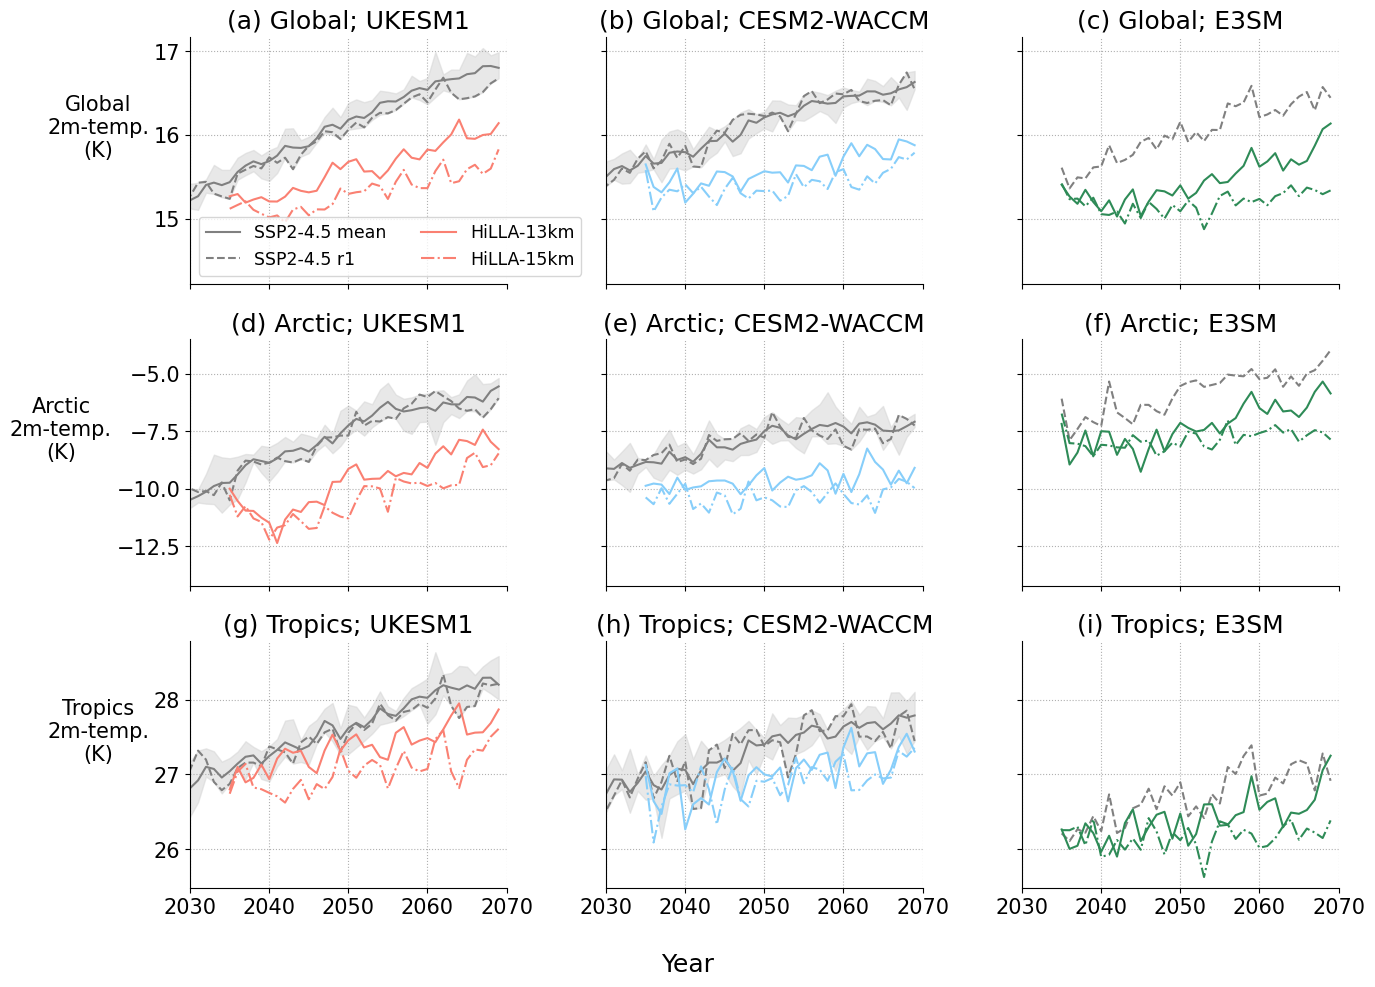

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(14, 10), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

piCo_global_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming
piCo_arctic_dict = {'UKESM':kelvinconv, 'CESM':kelvinconv, 'E3SM':kelvinconv} # fill in with PI values to shift from abs temps to warming


j=0
for model in models:
    i=0
    for region in ['Global', 'Arctic', 'Tropics']:
        ax = axs[i, j]
        
        ts_ssp245 = SSP245_timeseries_dict[model][region].tas
        piCo_global = piCo_global_dict[model]
        
        if model in ['UKESM', 'CESM']:
            ax.plot(ts_ssp245.mean('Ensemble_member').time.dt.year.values, (ts_ssp245.mean('Ensemble_member') - piCo_global), c=colours['ssp245'], label='SSP2-4.5 mean')
            ax.fill_between(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, 
                            ts_ssp245.min('Ensemble_member').values - piCo_global, 
                            ts_ssp245.max('Ensemble_member').values - piCo_global, 
                            color=colours['ssp245_light'], alpha=0.5)
        ax.plot(ts_ssp245.isel(Ensemble_member=0).time.dt.year.values, (ts_ssp245.isel(Ensemble_member=0) - piCo_global), c=colours['ssp245'], ls='--', label='SSP2-4.5 r1')
        for alt in HiLLA_altitudes:
            HiLLA = HiLLA_timeseries_dict[model][alt][region]
            ax.plot(HiLLA.time.dt.year,(HiLLA.tas - piCo_global),
            c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
        if region == 'Global':
            if model == 'UKESM':
                ax.legend(fontsize='small', ncols=2)
        i=i+1
    j=j+1

for ax in axs.flatten():
    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0, 0].set_title('(a) Global; UKESM1')
axs[0, 1].set_title('(b) Global; CESM2-WACCM')
axs[0, 2].set_title('(c) Global; E3SM')
axs[1, 0].set_title('(d) Arctic; UKESM1')
axs[1, 1].set_title('(e) Arctic; CESM2-WACCM')
axs[1, 2].set_title('(f) Arctic; E3SM')
axs[2, 0].set_title('(g) Tropics; UKESM1')
axs[2, 1].set_title('(h) Tropics; CESM2-WACCM')
axs[2, 2].set_title('(i) Tropics; E3SM')


axs[0, 0].set_ylabel('Global\n2m-temp.\n(K)', rotation=0, labelpad=40)
axs[1, 0].set_ylabel('Arctic\n2m-temp.\n(K)', rotation=0, labelpad=40)
axs[2, 0].set_ylabel('Tropics\n2m-temp.\n(K)', rotation=0, labelpad=40)

fig.supxlabel('Year')

plt.tight_layout()
plt.savefig('Figures/tas_summary_with_tropics.jpg', dpi=300)

In [8]:
import scipy

# print the AA ratio for the three models:
for model in models:
    ts_ssp245_global = SSP245_timeseries_dict[model]['Global'].mean('Ensemble_member').tas
    lr_global = scipy.stats.linregress(ts_ssp245_global.time.dt.year.values, ts_ssp245_global.values).slope

    ts_ssp245_arctic = SSP245_timeseries_dict[model]['Arctic'].mean('Ensemble_member').tas
    lr_arctic = scipy.stats.linregress(ts_ssp245_arctic.time.dt.year.values, ts_ssp245_arctic.values).slope

    print(model, lr_global, lr_arctic, lr_arctic/lr_global)

UKESM 0.04495670889132542 0.1418553299349646 3.1553762148798254
CESM 0.02973324308912759 0.05209927348332151 1.752223036254407
E3SM 0.03080569988316019 0.07986368566394149 2.592497036809693


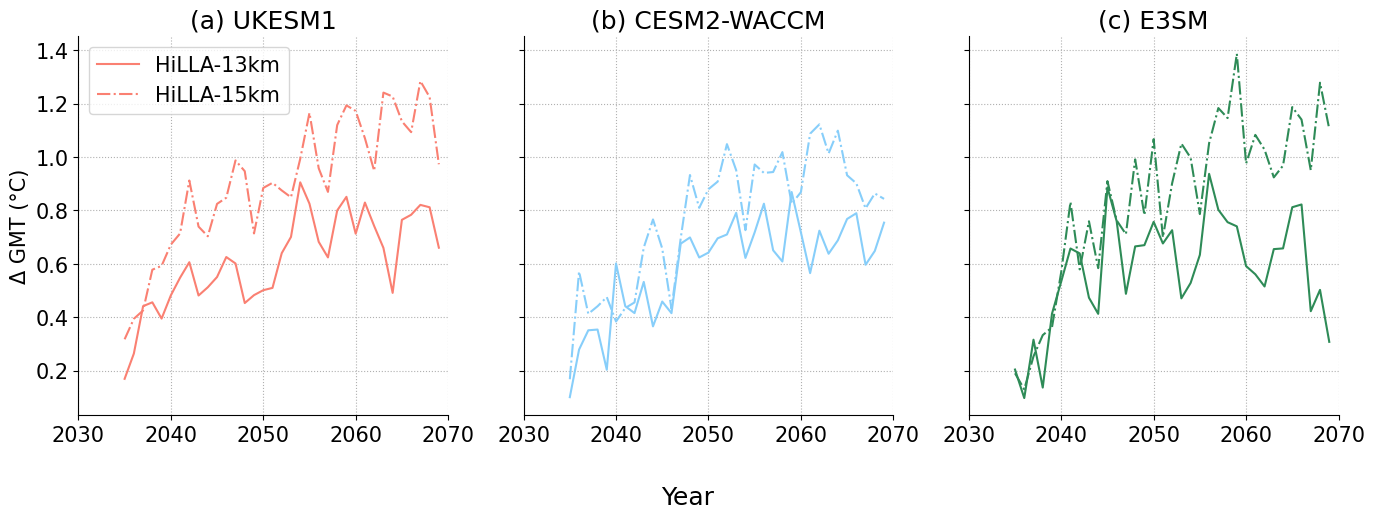

In [9]:
### show cooling mag evolutions: 


region = 'Global'

HiLLA_cooling_ts = SSP245_timeseries_dict[model][region].tas - HiLLA_timeseries_dict[model][alt][region].tas


fig, axs = plt.subplots(1, 3, figsize=(14, 5), sharey='row', sharex='col')
t_col = 'black'
alt_linestyles = {'13km':'solid', '15km':'-.'}

i=0
for model in models:
    ax = axs[i]

    for alt in ['13km', '15km']:
        HiLLA_cooling_ts = (SSP245_timeseries_dict[model][region].tas - HiLLA_timeseries_dict[model][alt][region].tas).mean('Ensemble_member')
        ax.plot(HiLLA_cooling_ts.time.dt.year,HiLLA_cooling_ts,
                c=model_colors[model], ls= alt_linestyles[alt], label='HiLLA-{}'.format(alt))
            
        ax.grid(ls='dotted')
    i=i+1

    ax.set_xlim(2030, 2070)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel('')
    ax.set_xlabel('')

axs[0].legend()
fig.supxlabel('Year')
axs[0].set_ylabel('\u0394 GMT (°C)')
plt.tight_layout()

axs[0].set_title('(a) UKESM1')
axs[1].set_title('(b) CESM2-WACCM')
axs[2].set_title('(c) E3SM')

plt.savefig('Figures/cooling_evolution_summary.jpg', dpi=300, bbox_inches='tight')

## now also plot the regional mean time mean cooling efficiencies

In [10]:
### need to also get ARISE temps

ds_list_tas = []
for path in glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/tas/gn/*/'):
    ds_list_tas.append(rename_cmip6(xr.open_mfdataset(path+'*.nc')))

DS_ARISE_tas_UK = weighted_annual_resample(xr.concat(ds_list_tas, dim='Ensemble_member').sel(time=slice('2015', '2069')), 'tas').rename({'x':'longitude', 'y':'latitude'})


## repeat for CESM
ds_list_tas = []
path = '/gws/nopw/j04/cpom/aduffey/ARISE/CESM/arise/TREFHT/'
files = os.listdir(path)
files = [x for x in files if ".nc" in x]

# we keep only first 5 members to align with the ssp245 runs available, this also means there are 5 members for both models
files = [x for x in files if int(x.split('.')[5]) < 6] 
for file in files:
    ds = rename_cmip6(xr.open_mfdataset(path+file))
    ds['Ensemble_member'] = file.split('.')[5]
    ds_list_tas.append(ds)
DS_ARISE_tas_CE = weighted_annual_resample(xr.concat(ds_list_tas, dim='Ensemble_member').sel(time=slice('2015', '2069')),'TREFHT')['TREFHT'].to_dataset(name='tas')
DS_ARISE_tas_CE = DS_ARISE_tas_CE.rename({'x':'longitude', 'y':'latitude'})


ARISE_data = {'UKESM':DS_ARISE_tas_UK,
              'CESM':DS_ARISE_tas_CE}


## save the ARISE cooling for use elsewhere:
ARISE_cooling_CESM = ARISE_data['CESM'].mean('Ensemble_member') - SSP245_data['CESM'].mean('Ensemble_member')
ARISE_cooling_CESM.to_netcdf('../intermediate_outputs/cooling_annual/CESM_ARISE_cooling.nc')

ARISE_cooling_UKESM = ARISE_data['UKESM'].mean('Ensemble_member') - SSP245_data['UKESM'].mean('Ensemble_member')
ARISE_cooling_UKESM.to_netcdf('../intermediate_outputs/cooling_annual/UKESM_ARISE_cooling.nc')

ARISE_cooling_dict = {'UKESM':ARISE_cooling_UKESM, 'CESM':ARISE_cooling_CESM}

## also get the regional timeseries
timeseries_dicts = []
for model in ['UKESM', 'CESM']:
    data = ARISE_data[model]
    timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region) for region in regions])))

ARISE_timeseries_dict = dict(zip(['UKESM', 'CESM'], timeseries_dicts))

In [11]:
def abs_temp(timeseries_ds):
    return timeseries_ds.sel(time=slice('2050', '2069')).mean(['time']).tas.values.item()


## reduce HiLLA temp data to single values for abs temp. over time period:
dicts_models = []
for model in models:
    for alt in HiLLA_altitudes:
        dicts_models.append(dict(zip(HiLLA_altitudes, [abs_temp(HiLLA_timeseries_dict[model][alt]['Global']) for alt in HiLLA_altitudes])))
HiLLA_abs_temps_dict = dict(zip(models, dicts_models))


### also get ARISE abs temps

ARISE_abs_temp_dict = {'UKESM':abs_temp(ARISE_timeseries_dict['UKESM']['Global'].mean('Ensemble_member')),
                       'CESM':abs_temp(ARISE_timeseries_dict['CESM']['Global'].mean('Ensemble_member'))}


UKESM Global
[1.5171331670507209, 1.3135438231628578, 1.5459447669218893, 1.4572384724285097, 1.425208304107132]
0.5755207136804188 0.9188111871959563
0.5964867386270366
CESM Global
[1.1874028715733655, 1.3760863735970803, 1.4544080100814456, 1.4543094603649178, 1.1776457272030427]
0.69654348795342 0.9330493365668531
0.33954211431698705
E3SM Global
0.6435642413106848 1.045420186050535
0.6244224258349551
UKESM Tropics
[1.3726989812399308, 1.1682860624688012, 1.426928110078631, 1.2904731982429738, 1.3194168643137751]
0.36412980758666436 0.7119602026562575
0.9552373571801261
CESM Tropics
[1.0899560484475213, 1.2516800098987144, 1.251385043676978, 1.2801191137304133, 1.0277074183295443]
0.40130680276166686 0.5453074086765923
0.3588292172571178
E3SM Tropics
0.3541474184875142 0.729632431774462
1.060250600980128
UKESM Arctic
[3.528694440620424, 3.3417699637644986, 3.579766401805635, 3.2307917591983255, 3.1043192629602]
2.1736757952300536 3.140835773178594
0.44494214825913353
CESM Arctic
[2.7

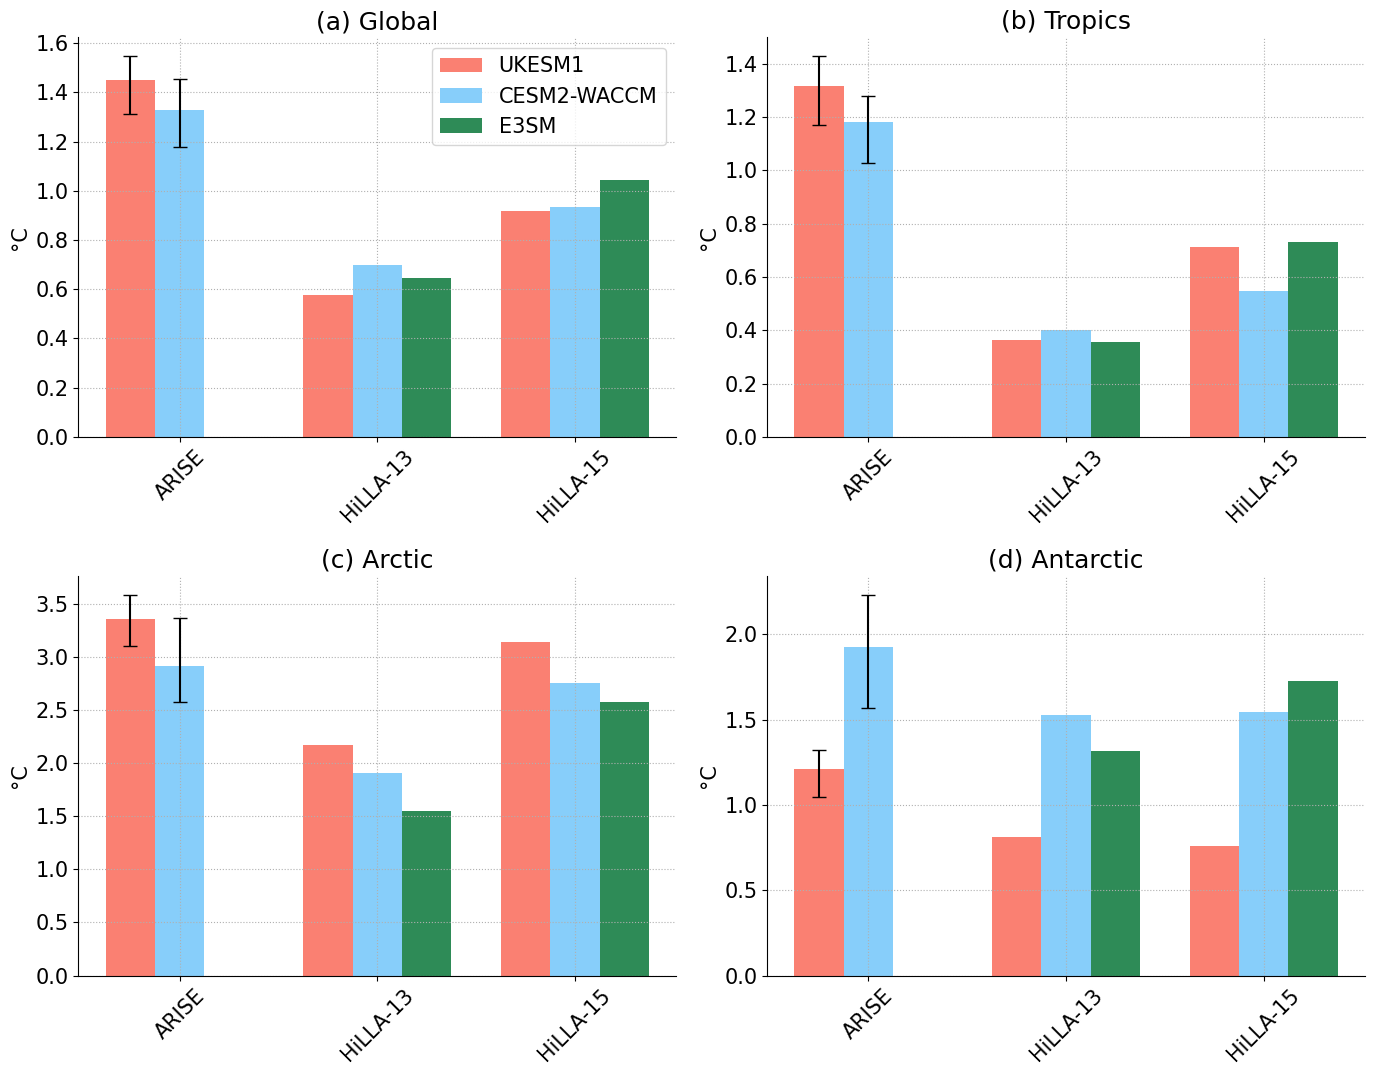

In [12]:
### plot regional coolings, v3 (combine all 4 sublots into one):


fig, axs = plt.subplots(2, 2, figsize=(14, 11))

run_labels = ['ARISE', 'HiLLA-13', 'HiLLA-15']
titles = ['(a) Global', '(b) Tropics', '(c) Arctic', '(d) Antarctic']
modeldict = {'UKESM':'UKESM1', 'CESM':'CESM2-WACCM', 'E3SM':'E3SM'}

x = np.arange(len(run_labels))  # bar positions
bar_width = 0.25  # width of each bar
offsets = [-bar_width, 0, bar_width]

l=0
for region in ['Global', 'Tropics', 'Arctic', 'Antarctic']:
    ax = axs.flatten()[l]
    i=0
    for model in models:
        print(model, region)
        if model != 'E3SM':
            
            ssp245_data = SSP245_timeseries_dict[model][region]
            mems = UKESM_ARISE_run_IDs
            arise_efficiencies = [-12*abs_temp((ARISE_timeseries_dict[model][region].isel(Ensemble_member=e) - ssp245_data.mean('Ensemble_member')))/list(arise_injs[model].values())[e] for e in range(5)]
            print(arise_efficiencies)
            arise_efficiency = np.mean(arise_efficiencies)
        if model == 'E3SM':
            arise_efficiency, arise_efficiencies = np.nan, [np.nan]
        HiLLA_13_cooling = abs_temp(HiLLA_timeseries_dict[model]['13km'][region]) - abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=0))
        HiLLA_15_cooling = abs_temp(HiLLA_timeseries_dict[model]['15km'][region]) - abs_temp(SSP245_timeseries_dict[model][region].isel(Ensemble_member=0))
        HiLLA_13_efficiency, HiLLA_15_efficiency =  -HiLLA_13_cooling, -HiLLA_15_cooling

        print(HiLLA_13_efficiency, HiLLA_15_efficiency)
        print((HiLLA_15_efficiency - HiLLA_13_efficiency)/HiLLA_13_efficiency)
        #print(arise_efficiency, HiLLA_13_efficiency, HiLLA_15_efficiency)
        ax.bar(x + offsets[i], 
               [arise_efficiency, HiLLA_13_efficiency, HiLLA_15_efficiency],
               width=bar_width, label=modeldict[model], color=model_colors[model],
               yerr=[[np.abs(np.min(arise_efficiencies) - arise_efficiency), np.nan, np.nan], 
                    [np.abs(np.max(arise_efficiencies) - arise_efficiency), np.nan, np.nan]],
                error_kw={'capsize':5})
        i=i+1
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(ls='dotted')
    ax.set_title(titles[l])
    ax.set_ylabel('°C')
    ax.set_xticks(x)
    ax.set_xticklabels(run_labels, rotation=45)
    #if l < 2:
    #    ax.set_ylim(None, 1.58)
    
    if l==0:
        ax.legend(fontsize='medium')
    l=l+1


plt.tight_layout()
plt.savefig('Figures/Regional_coolings_all.jpg', dpi=300, bbox_inches='tight')


# Now plot the maps currently done under 01d

In [13]:
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

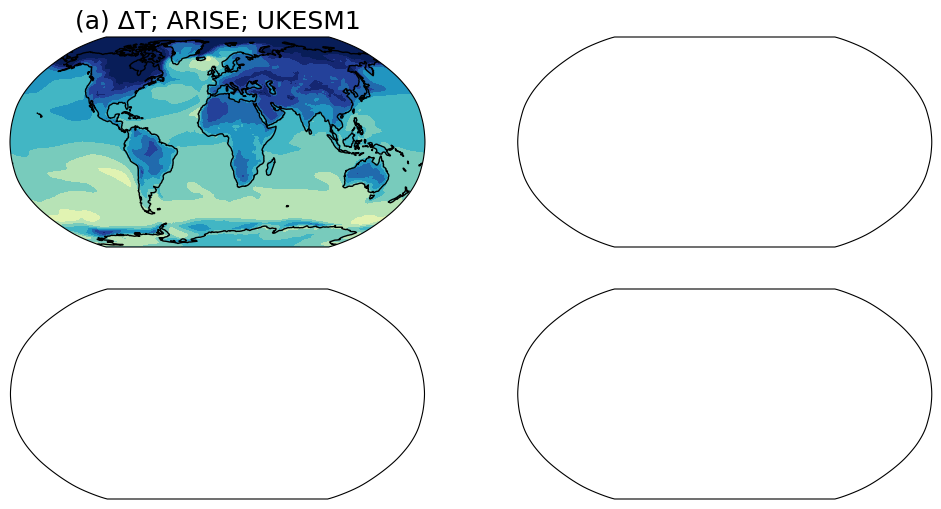

In [15]:

cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))


ax = axs.flatten()[0]
model = 'UKESM'
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = ARISE_cooling_dict[model].sel(time=slice('2050', '2069')).mean('time').tas/(np.mean([x for x in arise_injs[model].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

In [ ]:

cols = 'YlGnBu_r'
clevs=np.arange(-2.25,0.2,0.25) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(12,6))

for alt in 
ax = axs.flatten()[0]
model = 'UKESM'
ax.set_title('(a) \u0394T; ARISE; UKESM1')
d = ARISE_cooling_dict[model].tas/(np.mean([x for x in arise_injs[model].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[1]
ax.set_title('(b) \u0394T; HiLLA-15; UKESM1')
d = HILLS_15_cooling_UK.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[2]
ax.set_title('(c) \u0394T; ARISE; CESM2-WACCM')
d = ARISE_cooling_CE.tas/(np.mean([x for x in arise_injs['CESM'].values()])/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()

ax = axs.flatten()[3]
ax.set_title('(d) \u0394T; HiLLA-15; CESM2-WACCM')
d = HILLS_15_cooling_CE.tas/(12/10)
data,lons=add_cyclic_point(d,coord=d['longitude'])
cs=ax.contourf(lons,d['latitude'],data,clevs,
               transform = ccrs.PlateCarree(),
               cmap=cols,
               extend='both')
ax.coastlines()
#sig_mask,lons=add_cyclic_point(models_agree, coord=models_agree['x'])
#cs_hatch = ax.contourf(lons,models_agree['y'],sig_mask,
#                       transform = ccrs.PlateCarree(),
#                       levels=[0, 0.2, 1.2], colors='none',
 #                      hatches=[None,'..', '..'],
#                       extend='neither', zorder=1000)


plt.tight_layout()
# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0, top=1, left=0, right=0.85,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.87, 0.2, 0.05, 0.6])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='vertical')
cbar.set_label('\u0394T\nper 10Tg\ninjection\n(°C)', rotation=0, labelpad=40)
cbar.ax.yaxis.label.set_va('center')
#
plt.savefig('Figures/spatial_tas_response_abs_v2.jpg', dpi=300)